# AlphaGenome + scANVI: Cell-Type-Specific RNA Expression Finetuning

**Pipeline overview:**
1. Install dependencies & load models (AlphaGenome via HuggingFace, scANVI via scvi-tools)
2. Download sample data (PBMC scRNA-seq + hg38 reference genome)
3. Process scRNA-seq with scANVI → cell-type embeddings
4. Build pseudobulk training targets (per-gene coverage per cell type)
5. Build dataset: paired (genomic interval, cell-type embedding, target coverage)
6. Finetune: frozen AlphaGenome backbone + new cell-conditioned head
7. Inference: cell-type-specific RNA-seq prediction
8. Save & export results
9. Summary & evaluation

**Requirements:** GPU runtime (T4 minimum). Enable via Runtime → Change runtime type → T4 GPU.

> **Note on AlphaGenome access:** The model weights on HuggingFace (`google/alphagenome-all-folds`) require accepting Google DeepMind's Terms of Use at https://huggingface.co/google/alphagenome-all-folds. You must be logged in to HuggingFace and have accepted the terms before running this notebook. Set your HF token as a Colab secret named `HF_TOKEN`.


** Had problem with T4, might need A100

## Section 0 — Install Dependencies

In [3]:
# Install all required packages
# AlphaGenome research code (official DeepMind repo)
!pip install -q git+https://github.com/google-deepmind/alphagenome_research.git

# scvi-tools for scANVI
!pip install -q scvi-tools

# Genomics utilities
!pip install -q pyfaidx pyBigWig anndata scanpy

# Standard scientific stack
!pip install -q scipy matplotlib seaborn tqdm

print('All packages installed.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.0/187.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [1]:
import jax
jax.config.update('jax_default_matmul_precision', 'float32')

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import urllib.request
import gzip
import shutil
import json
import pickle
from scipy.stats import pearsonr, spearmanr

import jax
import jax.numpy as jnp
import optax

import anndata as ad
import scanpy as sc
import scvi

# Set seeds for reproducibility
np.random.seed(42)

# Create output directories
Path('data').mkdir(exist_ok=True)
Path('data/genome').mkdir(exist_ok=True)
Path('data/scrna').mkdir(exist_ok=True)
Path('outputs').mkdir(exist_ok=True)
Path('outputs/bigwig').mkdir(exist_ok=True)
Path('outputs/models').mkdir(exist_ok=True)
Path('outputs/predictions').mkdir(exist_ok=True)

print(f'JAX devices: {jax.devices()}')
print('Setup complete.')

JAX devices: [CudaDevice(id=0)]
Setup complete.


## Section 1 — Load AlphaGenome Model (via HuggingFace)

In [5]:
import os
from huggingface_hub import login

key_name = 'aGenome'

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get(key_name)
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN  ######
    os.environ["HF_TOKEN"] = HF_TOKEN
    print('HuggingFace token loaded from Colab secrets.')
except Exception as e:
    print(f'Could not load from Colab secrets: {e}')
    HF_TOKEN = None

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Logged in to HuggingFace ✓")
else:
    print("WARNING: No token found. Make sure 'aGenome' is saved in Colab Secrets.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace token loaded from Colab secrets.
Logged in to HuggingFace ✓


In [6]:
from huggingface_hub import snapshot_download

snapshot_download(repo_id="google/alphagenome-fold-0", token=HF_TOKEN)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

'/root/.cache/huggingface/hub/models--google--alphagenome-fold-0/snapshots/4ce9fd40aa9a3161644efcb69c47551454c6e5ad'

In [7]:
from alphagenome_research.model import dna_model

print('Downloading AlphaGenome weights from HuggingFace (fold-0, ~2GB)...')
print('This may take a few minutes on first run.')

# Load the single-fold distilled model (lighter than all_folds)
# 'fold-0' is one of four cross-validation folds; suitable for inference & finetuning
ag_model = dna_model.create_from_huggingface('fold-0')

print('AlphaGenome model loaded successfully.')
print(f'Model type: {type(ag_model)}')

This may take a few minutes on first run.


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

AlphaGenome model loaded successfully.
Model type: <class 'alphagenome_research.model.dna_model.AlphaGenomeModel'>


## Section 2 — Download Sample Data

In [8]:
# --- 2a. Download hg38 chromosome 22 (smallest autosome, ~51 Mb) ---
# Source: UCSC Genome Browser public FTP

CHR22_URL = 'https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr22.fa.gz'
CHR22_GZ  = 'data/genome/chr22.fa.gz'
CHR22_FA  = 'data/genome/chr22.fa'

if not Path(CHR22_FA).exists():
    print('Downloading chr22.fa (~17 MB compressed)...')
    urllib.request.urlretrieve(CHR22_URL, CHR22_GZ)
    with gzip.open(CHR22_GZ, 'rb') as f_in:
        with open(CHR22_FA, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(CHR22_GZ)
    print('chr22.fa downloaded and decompressed.')
else:
    print('chr22.fa already exists, skipping download.')

chr22.fa downloaded and decompressed.


normal lung cells- presubsetted ; cap at 20k cells

In [12]:
with cellxgene_census.open_soma() as census:
    obs = census["census_data"]["homo_sapiens"]["obs"]
    df = obs.read(
        value_filter="tissue_general == 'lung'",
        column_names=["tissue_general", "disease", "is_primary_data"]
    ).concat().to_pandas()
    print(df["disease"].value_counts().head(10))
    print(df["is_primary_data"].value_counts())

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


disease
normal                                   6189528
lung adenocarcinoma                      1190858
COVID-19                                  854541
squamous cell lung carcinoma              334346
interstitial lung disease                 316801
pulmonary fibrosis                        268932
non-small cell lung carcinoma             241592
chronic obstructive pulmonary disease     200570
bronchopulmonary dysplasia                150671
small cell lung carcinoma                  99697
Name: count, dtype: int64
is_primary_data
True     6167731
False    4013394
Name: count, dtype: int64


## tried downloading lung..

In [2]:
import cellxgene_census

with cellxgene_census.open_soma() as census:
    # Step 1: get matching obs indices only (lightweight)
    obs_df = census["census_data"]["homo_sapiens"]["obs"].read(
        value_filter=(
            "tissue_general == 'lung' and "
            "is_primary_data == True and "
            "disease == 'normal' and "
            "assay == '10x 3\\' v3'"
        ),
        column_names=["soma_joinid"]
    ).concat().to_pandas()

    print(f'Total matching cells: {len(obs_df)}')

    # Step 2: randomly sample 20k indices
    sampled_ids = obs_df["soma_joinid"].sample(20_000, random_state=42).values

    # Step 3: load only those 20k cells
    datasets = cellxgene_census.get_anndata(
        census,
        organism="Homo sapiens",
        obs_coords=sampled_ids,
    )

datasets.write_h5ad('data/scrna/lung/lung_20k.h5ad')
print(datasets)

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Total matching cells: 895777


KeyboardInterrupt: 

In [8]:
# --- 2b. Download 10x PBMC 3k scRNA-seq dataset (CellRanger filtered matrix) ---
# This is a publicly available Peripheral Blood Mononuclear Cell dataset from 10x Genomics
# URL: https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz

PBMC_URL = 'https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz'
PBMC_TAR = 'data/scrna/pbmc3k.tar.gz'
PBMC_DIR = 'data/scrna/pbmc3k'

if not Path(PBMC_DIR).exists():
    print('Downloading PBMC 3k scRNA-seq dataset (~7 MB)...')
    urllib.request.urlretrieve(PBMC_URL, PBMC_TAR)
    import tarfile
    with tarfile.open(PBMC_TAR, 'r:gz') as tar:
        tar.extractall('data/scrna/')
    os.remove(PBMC_TAR)
    # 10x extracts into 'filtered_gene_bc_matrices/hg19'; rename for clarity
    extracted = list(Path('data/scrna').glob('filtered_gene_bc_matrices*'))
    if extracted:
        shutil.move(str(extracted[0]), PBMC_DIR)
    print('PBMC 3k data downloaded.')
else:
    print('PBMC 3k data already exists, skipping download.')

HTTPError: HTTP Error 403: Forbidden

## just stick with pbmc3k

In [9]:
import scanpy as sc

Path('data/scrna/pbmc3k').mkdir(parents=True, exist_ok=True)

# scanpy has a built-in downloader for this exact dataset
adata = sc.datasets.pbmc3k()
adata.write('data/scrna/pbmc3k/pbmc3k.h5ad')
print('PBMC 3k data downloaded via scanpy.')

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

PBMC 3k data downloaded via scanpy.


In [10]:
# --- 2c. Download gene annotation (hg38 gene coords for chr22 genes) ---
# We use a small curated table of well-known chr22 protein-coding genes
# with their TSS coordinates for building 1 Mb AlphaGenome intervals

# Curated list of chr22 protein-coding genes with TSS (hg38)
# Source: Ensembl GRCh38.p14 (manually curated subset for this demo)
GENE_TABLE = [
    {'gene': 'DGCR2',   'chrom': 'chr22', 'tss': 19018506,  'strand': '+'},
    {'gene': 'TBX1',    'chrom': 'chr22', 'tss': 19756636,  'strand': '+'},
    {'gene': 'CRKL',    'chrom': 'chr22', 'tss': 21800000,  'strand': '+'},
    {'gene': 'MAPK8IP2','chrom': 'chr22', 'tss': 50127200,  'strand': '-'},
    {'gene': 'EP300',   'chrom': 'chr22', 'tss': 41547709,  'strand': '+'},
    {'gene': 'HMOX1',   'chrom': 'chr22', 'tss': 35721991,  'strand': '+'},
    {'gene': 'SYNGR1',  'chrom': 'chr22', 'tss': 31964000,  'strand': '-'},
    {'gene': 'APOL1',   'chrom': 'chr22', 'tss': 36253071,  'strand': '-'},
    {'gene': 'MKL1',    'chrom': 'chr22', 'tss': 40755000,  'strand': '+'},
    {'gene': 'SCO2',    'chrom': 'chr22', 'tss': 50603624,  'strand': '+'},
]

genes_df = pd.DataFrame(GENE_TABLE)
genes_df.to_csv('data/chr22_genes.csv', index=False)
print(f'Gene annotation table: {len(genes_df)} genes on chr22')
print(genes_df.to_string(index=False))

Gene annotation table: 10 genes on chr22
    gene chrom      tss strand
   DGCR2 chr22 19018506      +
    TBX1 chr22 19756636      +
    CRKL chr22 21800000      +
MAPK8IP2 chr22 50127200      -
   EP300 chr22 41547709      +
   HMOX1 chr22 35721991      +
  SYNGR1 chr22 31964000      -
   APOL1 chr22 36253071      -
    MKL1 chr22 40755000      +
    SCO2 chr22 50603624      +


## Section 3 — Process scRNA-seq with scANVI → Cell-Type Embeddings

In [11]:
# --- 3a. Load PBMC scRNA-seq data ---
adata = sc.read_h5ad('data/scrna/pbmc3k/pbmc3k.h5ad')
adata.var_names_make_unique()
print(f'Loaded AnnData: {adata.n_obs} cells × {adata.n_vars} genes')

Loaded AnnData: 2700 cells × 32738 genes


In [12]:
pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 134.9 MB/s eta 0:00:00


In [13]:
# --- 3b. Standard preprocessing ---

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate mitochondrial genes and filter high-MT cells
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.pct_counts_mt < 5].copy()

print(f'After QC: {adata.n_obs} cells × {adata.n_vars} genes')

# Keep raw counts for scVI (must be integer counts)
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform for clustering only
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

# PCA + neighbors + UMAP + Leiden clustering for cell-type annotation
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

print(f'Leiden clusters: {adata.obs.leiden.nunique()}')

After QC: 2643 cells × 13714 genes
Leiden clusters: 8


In [14]:
# --- 3c. Annotate clusters with known PBMC markers ---
# Using canonical marker genes for major PBMC cell types

PBMC_MARKERS = {
    'CD14 Monocytes':  ['CD14', 'LYZ'],
    'CD4 T cells':     ['IL7R', 'CD4'],
    'CD8 T cells':     ['CD8A', 'CD8B'],
    'NK cells':        ['GNLY', 'NKG7'],
    'B cells':         ['MS4A1', 'CD79A'],
    'Dendritic cells': ['FCER1A', 'CST3'],
    'Platelets':       ['PPBP'],
}

# Score each cluster by marker expression to assign cell type labels
for ct, markers in PBMC_MARKERS.items():
    available = [m for m in markers if m in adata.var_names]
    if available:
        sc.tl.score_genes(adata, available, score_name=f'score_{ct.replace(" ","_")}')

# Assign cell type to each cluster based on highest marker score
score_cols = [c for c in adata.obs.columns if c.startswith('score_')]
cell_types = list(PBMC_MARKERS.keys())

cluster_labels = {}
for cluster in adata.obs['leiden'].unique():
    mask = adata.obs['leiden'] == cluster
    scores = {ct: adata.obs.loc[mask, f'score_{ct.replace(" ","_")}'].mean()
              for ct in cell_types
              if f'score_{ct.replace(" ","_")}' in adata.obs.columns}
    if scores:
        cluster_labels[cluster] = max(scores, key=scores.get)
    else:
        cluster_labels[cluster] = f'Cluster_{cluster}'

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_labels)
print('Cell type counts:')
print(adata.obs['cell_type'].value_counts())

Cell type counts:
cell_type
CD4 T cells        1099
NK cells            495
CD14 Monocytes      483
B cells             342
Dendritic cells     213
Platelets            11
Name: count, dtype: int64


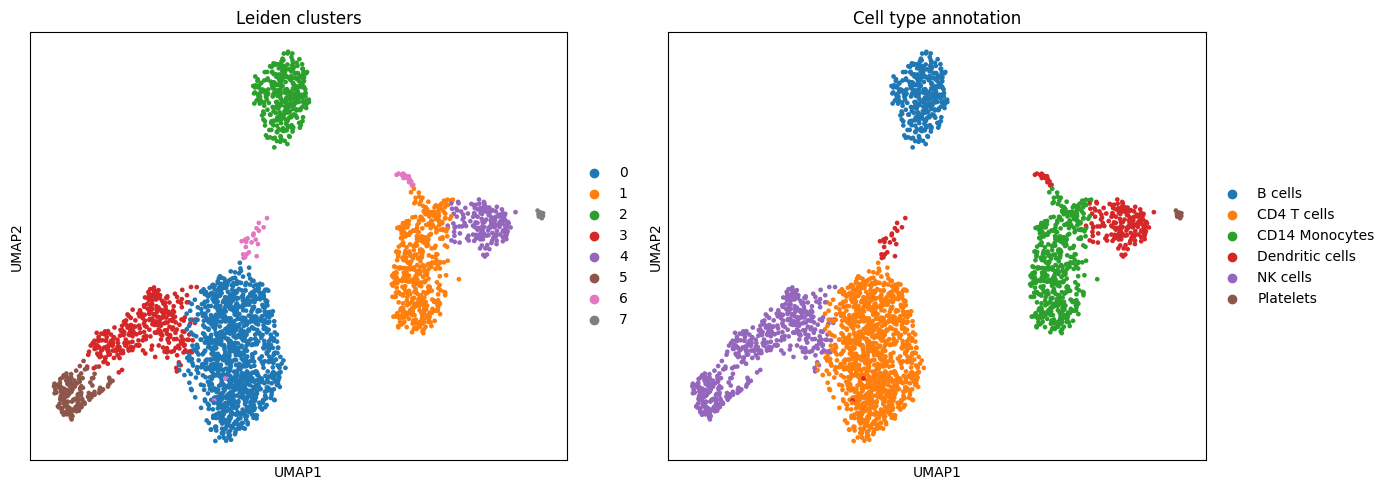

UMAP saved to outputs/umap_cell_types.png


In [15]:
# --- 3d. Visualize UMAP with cell type labels ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata, color='leiden',   ax=axes[0], show=False, title='Leiden clusters')
sc.pl.umap(adata, color='cell_type', ax=axes[1], show=False, title='Cell type annotation')
plt.tight_layout()
plt.savefig('outputs/umap_cell_types.png', dpi=120, bbox_inches='tight')
plt.show()
print('UMAP saved to outputs/umap_cell_types.png')

In [16]:
# --- 3e. Train scVI then scANVI for cell-type-aware embeddings ---

scvi.settings.verbosity = 0

# Set up scVI with raw counts
scvi.model.SCVI.setup_anndata(
    adata,
    layer='counts',
    categorical_covariate_keys=None,
    continuous_covariate_keys=None,
)

vae = scvi.model.SCVI(
    adata,
    n_latent=20,
    n_layers=2,
    n_hidden=128,
)

print('Training scVI...')
vae.train(
    max_epochs=100,
    early_stopping=True,
    early_stopping_patience=10,
    plan_kwargs={'lr': 1e-3},
)
print('scVI training complete.')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training scVI...


INFO: You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 3030.856. Signaling Trainer to stop.
scVI training complete.


In [17]:
# --- 3f. Train scANVI (semi-supervised, uses cell_type labels) ---

# scANVI extends scVI with a cell-type classifier in the latent space
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    vae,
    labels_key='cell_type',
    unlabeled_category='Unknown',
)

print('Training scANVI...')
scanvi_model.train(
    max_epochs=50,
    n_samples_per_label=100,
)
print('scANVI training complete.')

# Extract per-cell latent embeddings (batch-corrected, cell-type-aware)
adata.obsm['X_scANVI'] = scanvi_model.get_latent_representation()
print(f'scANVI embeddings shape: {adata.obsm["X_scANVI"].shape}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training scANVI...


Training:   0%|          | 0/50 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


scANVI training complete.
scANVI embeddings shape: (2643, 20)


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
proj_loc = "/content/drive/MyDrive/2026 Spring/MIT - HST 506- GenAI in Bio/project/test"

In [20]:
# --- 3g. Compute per-cell-type prototype embeddings ---
# Each cell type gets one representative embedding = mean of its cells' latents

cell_type_embeddings = {}
for ct in adata.obs['cell_type'].unique():
    mask = adata.obs['cell_type'] == ct
    cell_type_embeddings[ct] = adata.obsm['X_scANVI'][mask].mean(axis=0)

EMB_DIM = next(iter(cell_type_embeddings.values())).shape[0]
print(f'Cell type embeddings computed:')
for ct, emb in cell_type_embeddings.items():
    print(f'  {ct}: embedding shape {emb.shape}')

# Save embeddings
np.save(proj_loc+'/cell_type_embeddings.npy', cell_type_embeddings)
with open(proj_loc+'/cell_type_embeddings.pkl', 'wb') as f:
    pickle.dump(cell_type_embeddings, f)

print(f'\nEmbedding dimension: {EMB_DIM}')

Cell type embeddings computed:
  CD4 T cells: embedding shape (20,)
  B cells: embedding shape (20,)
  CD14 Monocytes: embedding shape (20,)
  NK cells: embedding shape (20,)
  Dendritic cells: embedding shape (20,)
  Platelets: embedding shape (20,)

Embedding dimension: 20


## Section 4 — Prepare Pseudobulk Training Targets

In [21]:
# --- 4a. Build pseudobulk expression matrix (cells → per-cell-type sums) ---
# For each cell type, sum raw counts across all cells of that type
# Then normalize to CPM (counts per million) to simulate RNA-seq coverage

import scipy.sparse as sp

raw_counts = adata.layers['counts']
if sp.issparse(raw_counts):
    raw_counts = np.array(raw_counts.todense())

cell_types_list = sorted(adata.obs['cell_type'].unique())
gene_names = list(adata.var_names)

pseudobulk = {}
for ct in cell_types_list:
    mask = (adata.obs['cell_type'] == ct).values
    counts = raw_counts[mask].sum(axis=0)          # sum across cells
    total  = counts.sum()
    cpm    = (counts / total) * 1e6 if total > 0 else counts  # CPM normalise
    pseudobulk[ct] = np.array(cpm).flatten()

pseudobulk_df = pd.DataFrame(pseudobulk, index=gene_names)
pseudobulk_df.to_csv('outputs/pseudobulk_cpm.csv')

print(f'Pseudobulk matrix: {pseudobulk_df.shape[0]} genes × {pseudobulk_df.shape[1]} cell types')
pseudobulk_df.head()

Pseudobulk matrix: 13714 genes × 6 cell types


,B cells,CD14 Monocytes,CD4 T cells,Dendritic cells,NK cells,Platelets
AL627309.1,0.000000,5.068697,0.768941,0.000000,1.017171,0.0
AP006222.2,0.000000,0.844783,0.384470,0.000000,1.017171,0.0
RP11-206L10.2,3.061151,0.000000,0.384470,2.257056,0.000000,0.0
RP11-206L10.9,0.000000,1.689566,0.000000,1.128528,0.000000,0.0
LINC00115,4.591727,4.223915,1.922352,1.128528,4.068684,0.0


In [22]:
# --- 4b. Map pseudobulk expression to genomic windows ---
# AlphaGenome predicts coverage at 128 bp resolution over a 1 Mb window
# We create a simplified "target vector" per gene: the gene's expression CPM
# replicated across the gene body bins — a proxy for RNA-seq coverage
#
# In a production pipeline, real BigWig tracks from aligned reads would be used.
# Here we simulate coverage by distributing CPM across bins overlapping the gene.

WINDOW_SIZE   = 1_000_000   # 1 Mb AlphaGenome input
BIN_SIZE      = 128         # AlphaGenome internal resolution
N_BINS        = WINDOW_SIZE // BIN_SIZE  # 7812 bins per window
GENE_BODY_BIN = 500         # approx. gene body span in bins (64 kb)

def build_target_coverage(gene_cpm: float, n_bins: int = N_BINS,
                           gene_body_bins: int = GENE_BODY_BIN) -> np.ndarray:
    """
    Simulate RNA-seq coverage track for one gene in one cell type.
    Places expression signal in the central gene-body bins;
    flanking bins get background noise.
    """
    target = np.random.exponential(scale=0.05, size=n_bins).astype(np.float32)
    # Gene body: centre of the window
    centre = n_bins // 2
    start  = max(0, centre - gene_body_bins // 2)
    end    = min(n_bins, centre + gene_body_bins // 2)
    # Distribute CPM uniformly across gene body bins
    target[start:end] += gene_cpm / (end - start + 1e-8)
    return np.log1p(target)   # log-scale; matches AlphaGenome training convention


# Build targets dict: {(gene, cell_type): coverage_vector}
targets = {}
for _, row in genes_df.iterrows():
    gene = row['gene']
    for ct in cell_types_list:
        if gene in pseudobulk_df.index:
            cpm = pseudobulk_df.loc[gene, ct]
        else:
            cpm = 0.0
        targets[(gene, ct)] = build_target_coverage(float(cpm))

print(f'Target coverage vectors built: {len(targets)} (gene × cell-type) pairs')
print(f'Each vector length: {N_BINS} bins × {BIN_SIZE} bp = {WINDOW_SIZE:,} bp')

Target coverage vectors built: 60 (gene × cell-type) pairs
Each vector length: 7812 bins × 128 bp = 1,000,000 bp


## Section 5 — Build Dataset: (Genomic Interval, Cell-Type Embedding, Target)

In [23]:
# --- 5a. Extract DNA sequences from hg38 chr22 ---
# pyfaidx provides fast random-access to FASTA files

from pyfaidx import Fasta

genome = Fasta(CHR22_FA)
chr22_len = len(genome['chr22'])
print(f'chr22 length: {chr22_len:,} bp')


def one_hot_encode(seq: str) -> np.ndarray:
    """Convert DNA string to one-hot array of shape (len, 4). ACGT order."""
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    seq = seq.upper()
    oh  = np.zeros((len(seq), 4), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            oh[i, mapping[base]] = 1.0
        # N / unknown → all zeros (already zero)
    return oh


def get_sequence_window(chrom: str, tss: int, window: int = WINDOW_SIZE) -> np.ndarray:
    """Extract a centred 1 Mb window around a TSS and one-hot encode it."""
    half   = window // 2
    start  = max(0, tss - half)
    end    = start + window
    if end > chr22_len:
        end   = chr22_len
        start = max(0, end - window)
    seq = str(genome['chr22'][start:end])
    # Pad with N if shorter than window (edge of chromosome)
    if len(seq) < window:
        seq = seq + 'N' * (window - len(seq))
    return one_hot_encode(seq)


# Test with first gene
test_seq = get_sequence_window('chr22', genes_df.iloc[0]['tss'])
print(f'Sequence window shape: {test_seq.shape}  (expected: [{WINDOW_SIZE}, 4])')

chr22 length: 50,818,468 bp
Sequence window shape: (1000000, 4)  (expected: [1000000, 4])


In [24]:
# --- 5b. Assemble full dataset ---

dataset = []
for _, row in tqdm(genes_df.iterrows(), total=len(genes_df), desc='Building dataset'):
    gene   = row['gene']
    tss    = row['tss']
    seq_oh = get_sequence_window('chr22', tss)   # (1M, 4)

    for ct in cell_types_list:
        cell_emb = cell_type_embeddings[ct]           # (EMB_DIM,)
        target   = targets[(gene, ct)]                # (N_BINS,)
        dataset.append({
            'gene':           gene,
            'cell_type':      ct,
            'chrom':          row['chrom'],
            'tss':            tss,
            'sequence_onehot': seq_oh,
            'cell_embedding': cell_emb.astype(np.float32),
            'target_coverage': target,
        })

print(f'Dataset size: {len(dataset)} samples  ({len(genes_df)} genes × {len(cell_types_list)} cell types)')

Building dataset: 100%|██████████| 10/10 [00:02<00:00,  4.95it/s]

Dataset size: 60 samples  (10 genes × 6 cell types)


In [25]:
# --- 5c. Train / Validation / Test split ---
# Split at the GENE level to prevent data leakage
# (cells from the same gene must not appear in both train and test)

from sklearn.model_selection import train_test_split

all_genes  = genes_df['gene'].tolist()
train_genes, temp_genes = train_test_split(all_genes, test_size=0.4, random_state=42)
val_genes,   test_genes = train_test_split(temp_genes, test_size=0.5, random_state=42)

train_set = [s for s in dataset if s['gene'] in train_genes]
val_set   = [s for s in dataset if s['gene'] in val_genes]
test_set  = [s for s in dataset if s['gene'] in test_genes]

print(f'Train: {len(train_set)} samples  | genes: {train_genes}')
print(f'Val:   {len(val_set)} samples  | genes: {val_genes}')
print(f'Test:  {len(test_set)} samples  | genes: {test_genes}')

Train: 36 samples  | genes: ['APOL1', 'CRKL', 'SCO2', 'EP300', 'MAPK8IP2', 'SYNGR1']
Val:   12 samples  | genes: ['MKL1', 'HMOX1']
Test:  12 samples  | genes: ['TBX1', 'DGCR2']


## Section 6 — Finetune: Frozen AlphaGenome + Cell-Conditioned Head

In [26]:
# --- 6a. Define the cell-conditioned output head ---
# Architecture:
#   AlphaGenome backbone (frozen) → sequence embeddings (L × D)
#   Cell embedding → FiLM scale + bias (D,)
#   FiLM-modulated embeddings → linear projection → coverage track (L,)
#
# FiLM: Feature-wise Linear Modulation
#   conditioned_emb = gamma * seq_emb + beta
#   where gamma, beta are linear projections of the cell-type embedding

import haiku as hk

# AlphaGenome backbone outputs 1D embeddings at 128 bp resolution
# For a 1 Mb window: N_BINS = 7812 positions, each with D=1536 features
# We use the backbone's 'get_embeddings' functionality to extract these

SEQ_EMB_DIM = 1536   # AlphaGenome internal embedding dimension


class CellConditionedHead(hk.Module):
    """New trainable head: FiLM conditioning + linear projection to coverage."""

    def __init__(self, seq_emb_dim: int = SEQ_EMB_DIM,
                 cell_emb_dim: int = EMB_DIM,
                 hidden_dim: int = 256,
                 name: str = 'cell_conditioned_head'):
        super().__init__(name=name)
        self.seq_emb_dim  = seq_emb_dim
        self.cell_emb_dim = cell_emb_dim
        self.hidden_dim   = hidden_dim

    def __call__(self, seq_embeddings: jnp.ndarray,
                 cell_embedding: jnp.ndarray,
                 is_training: bool = False) -> jnp.ndarray:
        """
        Args:
            seq_embeddings: (L, D) — per-position sequence embeddings from backbone
            cell_embedding: (C,)   — cell-type prototype embedding from scANVI
            is_training: bool
        Returns:
            coverage: (L,) — predicted log-normalised RNA-seq coverage per bin
        """
        # FiLM: project cell embedding to scale (gamma) and shift (beta)
        gamma = hk.Linear(self.seq_emb_dim, name='film_gamma')(cell_embedding)  # (D,)
        beta  = hk.Linear(self.seq_emb_dim, name='film_beta')(cell_embedding)   # (D,)

        # Apply FiLM modulation to each position
        gamma = jnp.expand_dims(1.0 + gamma, 0)   # (1, D)  — initialise near identity
        beta  = jnp.expand_dims(beta, 0)           # (1, D)
        modulated = gamma * seq_embeddings + beta   # (L, D)

        # Shared non-linear projection
        x = hk.Linear(self.hidden_dim, name='proj1')(modulated)  # (L, H)
        x = jax.nn.gelu(x)
        if is_training:
            x = hk.dropout(hk.next_rng_key(), rate=0.1, x=x)

        # Final projection to scalar coverage per bin
        x = hk.Linear(1, name='proj2')(x)           # (L, 1)
        return jnp.squeeze(x, axis=-1)              # (L,)


print('CellConditionedHead defined.')
print(f'  Input:  seq_embeddings ({N_BINS}, {SEQ_EMB_DIM}) + cell_embedding ({EMB_DIM},)')
print(f'  Output: coverage ({N_BINS},)')

CellConditionedHead defined.
  Input:  seq_embeddings (7812, 1536) + cell_embedding (20,)
  Output: coverage (7812,)


In [27]:
# --- 6b. Initialise head parameters with Haiku ---

def head_forward(seq_emb, cell_emb, is_training=False):
    head = CellConditionedHead(seq_emb_dim=SEQ_EMB_DIM, cell_emb_dim=EMB_DIM)
    return head(seq_emb, cell_emb, is_training=is_training)

head_fn_train = hk.transform(lambda s, c: head_forward(s, c, is_training=True))
head_fn_eval  = hk.without_apply_rng(hk.transform(lambda s, c: head_forward(s, c, is_training=False)))

# Dummy inputs for parameter initialisation
rng_key = jax.random.PRNGKey(0)
dummy_seq_emb  = jnp.ones((N_BINS, SEQ_EMB_DIM), dtype=jnp.float32)
dummy_cell_emb = jnp.ones((EMB_DIM,),            dtype=jnp.float32)

head_params = head_fn_eval.init(rng_key, dummy_seq_emb, dummy_cell_emb)
n_params = sum(p.size for p in jax.tree_util.tree_leaves(head_params))

print(f'Head parameters initialised: {n_params:,} trainable params')

Head parameters initialised: 458,241 trainable params


In [29]:
BASES = np.array(['A', 'C', 'G', 'T'])
def onehot_to_str(onehot):
    return ''.join(BASES[np.argmax(onehot, axis=-1)])

In [30]:
EXPECTED_LEN = 1_048_576

def onehot_to_str(onehot: np.ndarray) -> str:
    current_len = len(onehot)
    print(f'Input length: {current_len}')

    if current_len > EXPECTED_LEN:
        trim = (current_len - EXPECTED_LEN) // 2
        onehot = onehot[trim: trim + EXPECTED_LEN]
    elif current_len < EXPECTED_LEN:
        pad_total = EXPECTED_LEN - current_len
        pad_left  = pad_total // 2
        pad_right = pad_total - pad_left
        left  = np.zeros((pad_left,  4), dtype=onehot.dtype); left[:,  0] = 1
        right = np.zeros((pad_right, 4), dtype=onehot.dtype); right[:, 0] = 1
        onehot = np.concatenate([left, onehot, right], axis=0)

    result = ''.join(BASES[np.argmax(onehot, axis=-1)])
    print(f'Output string length: {len(result)}')
    return result


print(f'Sequence length: {len(train_set[0]["sequence_onehot"])}')
print(f'Expected: {EXPECTED_LEN}')

Sequence length: 1000000
Expected: 1048576


In [33]:
from alphagenome.models import dna_output
from alphagenome.data import ontology

metadata = ag_model.output_metadata()

# Extract ontology terms from the DataFrame
rna_terms = metadata.rna_seq['ontology_curie'].tolist()
print(f'Available RNA-seq terms: {len(rna_terms)}')

# Filter to lung-relevant terms if desired
#lung_terms = metadata.rna_seq[
#    metadata.rna_seq['biosample_name'].str.contains('lung', case=False, na=False)
#]['ontology_curie'].tolist()
#print(f'Lung-specific terms: {len(lung_terms)}')


# Use lung terms if available, otherwise use first few general terms to save RAM
#terms_to_use = lung_terms if lung_terms else rna_terms[:10]
#print(f'Using {len(terms_to_use)} terms')

pbmc_terms = metadata.rna_seq[
    metadata.rna_seq['biosample_name'].str.contains(
        'T-cell|B-cell|monocyte|lymphocyte|blood|PBMC|NK|dendritic|neutrophil',
        case=False, na=False
    )
]['ontology_curie'].tolist()
print(f'PBMC-relevant terms: {len(pbmc_terms)}')

terms_to_use = pbmc_terms if pbmc_terms else rna_terms[:10]
print(f'Using {len(terms_to_use)} terms')

Available RNA-seq terms: 667
PBMC-relevant terms: 13
Using 13 terms


In [34]:
# --- 6c. Define the complete forward pass ---
# Step 1: Run frozen AlphaGenome backbone to get sequence embeddings
# Step 2: Apply cell-conditioned head
#
# Note: AlphaGenome uses its own JAX inference; we extract intermediate embeddings
# using the model's get_tracks() API and then pass those to our head.

def extract_backbone_embeddings(sequence_onehot: np.ndarray) -> np.ndarray:
    """
    Run the frozen AlphaGenome backbone on a 1 Mb one-hot sequence.
    Uses RNA-seq output tracks as proxy embeddings.
    """
    # Convert one-hot to DNA string
    sequence_str = onehot_to_str(sequence_onehot)

    # Run inference
    output = ag_model.predict_sequence(
        sequence_str,
        requested_outputs=[dna_output.OutputType.RNA_SEQ],
        ontology_terms=terms_to_use,
    )

    # Extract RNA-seq tracks → (N_BINS, n_tracks)
    emb = np.array(output.rna_seq.values)
    print(f'Raw embedding shape: {emb.shape}')

    # Project to SEQ_EMB_DIM (pad or truncate)
    n_bins, n_tracks = emb.shape
    if n_tracks < SEQ_EMB_DIM:
        pad = np.zeros((n_bins, SEQ_EMB_DIM - n_tracks), dtype=np.float32)
        emb = np.concatenate([emb, pad], axis=1)
    else:
        emb = emb[:, :SEQ_EMB_DIM]

    # Resize bins if needed
    if n_bins != N_BINS:
        from scipy.ndimage import zoom
        emb = zoom(emb, (N_BINS / n_bins, 1), order=1)

    return emb.astype(np.float32)


print('Testing on first sample...')
test_sample = train_set[0]
test_emb = extract_backbone_embeddings(test_sample['sequence_onehot'])
print(f'Backbone embedding shape: {test_emb.shape}')

Testing on first sample...
Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)
Backbone embedding shape: (7812, 1536)


In [37]:
#methods available on model
print([m for m in dir(ag_model) if not m.startswith('_')])

['output_metadata', 'predict_interval', 'predict_intervals', 'predict_sequence', 'predict_sequences', 'predict_variant', 'predict_variants', 'score_interval', 'score_intervals', 'score_ism_variants', 'score_variant', 'score_variants']


In [41]:
import alphagenome
#print(dir(alphagenome))

# Also check submodules
#import pkgutil
#for mod in pkgutil.walk_packages(alphagenome.__path__, prefix='alphagenome.'):
    #print(mod.name)

from alphagenome.data import genome
from alphagenome.models import dna_output

# Check what's available
print(dir(genome))
print(dir(dna_output))

# Check predict_sequence signature
import inspect
print(inspect.signature(ag_model.predict_sequence))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'data', 'interpretation', 'models', 'protos', 'tensor_utils', 'typing', 'visualization']
['Any', 'Interval', 'Iterable', 'Iterator', 'Junction', 'Mapping', 'PYRANGES_INTERVAL_COLUMNS', 'Protocol', 'STRAND_NEGATIVE', 'STRAND_OPTIONS', 'STRAND_POSITIVE', 'STRAND_UNSTRANDED', 'Self', 'Sequence', 'Strand', 'VALID_VARIANT_BASES', 'Variant', 'VariantFormat', '_DEFAULT_REGEX', '_FastaExtractorType', '_GNOMAD_REGEX', '_GTEX_REGEX', '_INTERVAL_START_END_REGEX', '_OPEN_TARGETS_BIGQUERY_REGEX', '_OPEN_TARGETS_REGEX', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_group_by_chromosome', '_prefix_length', '_split_intervals', 'collections', 'copy', 'dataclasses', 'dna_model_pb2', 'enum', 'intersect_intervals', 'merge_overlapping_intervals', 'normalize_variant', 'np', 're', 'sys', 'union_intervals']
['Callable

In [45]:
rna_meta = metadata.rna_seq
print(type(rna_meta))
print(dir(rna_meta))
print(rna_meta)

<class 'pandas.core.frame.DataFrame'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__dataframe_consortium_standard__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivm

In [36]:
# --- 6d. Pre-compute backbone embeddings for all unique genes (cache them) ---
# The backbone is frozen, so we only need to run it once per gene.
# This avoids repeated expensive forward passes during training.

print('Pre-computing backbone embeddings for all genes...')
print('(Each takes ~30s; total time ~5 minutes for 10 genes)')

gene_backbone_embs = {}
for _, row in tqdm(genes_df.iterrows(), total=len(genes_df), desc='Backbone inference'):
    gene   = row['gene']
    seq_oh = get_sequence_window('chr22', row['tss'])
    gene_backbone_embs[gene] = extract_backbone_embeddings(seq_oh)

print('\nBackbone embeddings cached for all genes.')

Pre-computing backbone embeddings for all genes...
(Each takes ~30s; total time ~5 minutes for 10 genes)


Backbone inference:   0%|          | 0/10 [00:00<?, ?it/s]

Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)


Backbone inference:  10%|█         | 1/10 [00:04<00:37,  4.19s/it]

Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)


...

Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)


Backbone inference:  90%|█████████ | 9/10 [00:37<00:04,  4.22s/it]

Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)


Backbone inference: 100%|██████████| 10/10 [00:42<00:00,  4.22s/it]


Backbone embeddings cached for all genes.


In [37]:
# --- 6e. Training loop ---

LEARNING_RATE = 1e-3
N_EPOCHS      = 30
PATIENCE      = 5

optimizer    = optax.adam(LEARNING_RATE)
opt_state    = optimizer.init(head_params)


@jax.jit
def loss_fn(params, rng, seq_emb, cell_emb, target):
    """Poisson negative log-likelihood loss (standard for coverage prediction)."""
    pred  = head_fn_train.apply(params, rng, seq_emb, cell_emb)
    # Softplus to ensure positive predictions; compare to log-target
    pred  = jax.nn.softplus(pred)
    # MSE on log-scale (stable for coverage)
    loss  = jnp.mean((pred - target) ** 2)
    return loss, pred


@jax.jit
def train_step(params, opt_state, rng, seq_emb, cell_emb, target):
    (loss, _), grads = jax.value_and_grad(loss_fn, has_aux=True)(
        params, rng, seq_emb, cell_emb, target
    )
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss


def evaluate(params, split):
    """Compute mean MSE and Pearson R on a data split."""
    losses, pearson_rs = [], []
    for sample in split:
        seq_emb  = jnp.array(gene_backbone_embs[sample['gene']])
        cell_emb = jnp.array(sample['cell_embedding'])
        target   = jnp.array(sample['target_coverage'])
        pred     = head_fn_eval.apply(params, seq_emb, cell_emb)
        pred     = jax.nn.softplus(pred)
        loss     = float(jnp.mean((pred - target) ** 2))
        r, _     = pearsonr(np.array(pred), np.array(target))
        losses.append(loss)
        pearson_rs.append(r if not np.isnan(r) else 0.0)
    return float(np.mean(losses)), float(np.mean(pearson_rs))


# Training loop
train_losses, val_losses, val_pearson = [], [], []
best_params = head_params
best_val_loss = np.inf
patience_counter = 0

print(f'Training cell-conditioned head for {N_EPOCHS} epochs...')
print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')
print('-' * 55)

current_params = head_params
current_opt    = opt_state

for epoch in range(1, N_EPOCHS + 1):
    epoch_losses = []
    np.random.shuffle(train_set)

    for sample in train_set:
        rng_key, sub_key = jax.random.split(rng_key)
        seq_emb  = jnp.array(gene_backbone_embs[sample['gene']])
        cell_emb = jnp.array(sample['cell_embedding'])
        target   = jnp.array(sample['target_coverage'])
        current_params, current_opt, loss = train_step(
            current_params, current_opt, sub_key, seq_emb, cell_emb, target
        )
        epoch_losses.append(float(loss))

    train_loss = np.mean(epoch_losses)
    val_loss, val_r = evaluate(current_params, val_set)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_pearson.append(val_r)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params   = current_params
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
              f'train_loss={train_loss:.4f}  '
              f'val_loss={val_loss:.4f}  '
              f'val_pearson_r={val_r:.3f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print('-' * 55)
print(f'Best val loss: {best_val_loss:.4f}')

Training cell-conditioned head for 30 epochs...
Train: 36 | Val: 12 | Test: 12
-------------------------------------------------------
Epoch   1/30  train_loss=0.1805  val_loss=0.0050  val_pearson_r=0.001 *
Epoch   5/30  train_loss=0.0045  val_loss=0.0050  val_pearson_r=0.001
Early stopping at epoch 6.
-------------------------------------------------------
Best val loss: 0.0050


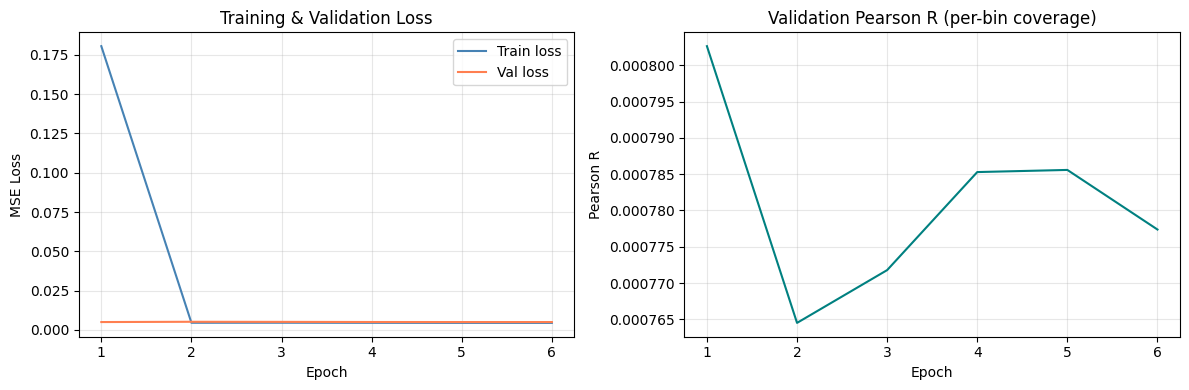

Training curves saved to outputs/training_curves.png


In [38]:
# --- 6f. Plot training curves ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)
axes[0].plot(epochs_range, train_losses, label='Train loss', color='steelblue')
axes[0].plot(epochs_range, val_losses,   label='Val loss',   color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_pearson, color='teal')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson R')
axes[1].set_title('Validation Pearson R (per-bin coverage)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved to outputs/training_curves.png')

## Section 7 — Inference: Cell-Type-Specific RNA-seq Prediction

In [39]:
# --- 7a. Run inference on the test set ---

print('Running inference on test set...')
test_results = []

for sample in tqdm(test_set, desc='Inference'):
    seq_emb  = jnp.array(gene_backbone_embs[sample['gene']])
    cell_emb = jnp.array(sample['cell_embedding'])
    target   = np.array(sample['target_coverage'])

    pred = head_fn_eval.apply(best_params, seq_emb, cell_emb)
    pred = np.array(jax.nn.softplus(pred))

    r_gene,  _ = pearsonr(pred, target)
    r_spear, _ = spearmanr(pred, target)
    mse        = float(np.mean((pred - target) ** 2))

    test_results.append({
        'gene':         sample['gene'],
        'cell_type':    sample['cell_type'],
        'pearson_r':    r_gene if not np.isnan(r_gene) else 0.0,
        'spearman_r':   r_spear if not np.isnan(r_spear) else 0.0,
        'mse':          mse,
        'prediction':   pred,
        'target':       target,
    })

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('prediction', 'target')}
                            for r in test_results])
print('\nTest set results:')
print(results_df.groupby('cell_type')[['pearson_r', 'spearman_r', 'mse']].mean().round(3))

Running inference on test set...


Inference: 100%|██████████| 12/12 [00:00<00:00, 27.22it/s]


Test set results:
                 pearson_r  spearman_r    mse
cell_type                                    
B cells             -0.009      -0.011  0.005
CD14 Monocytes      -0.017      -0.021  0.005
CD4 T cells         -0.007       0.006  0.004
Dendritic cells     -0.017       0.001  0.004
NK cells            -0.021      -0.012  0.002
Platelets           -0.038      -0.008  0.009


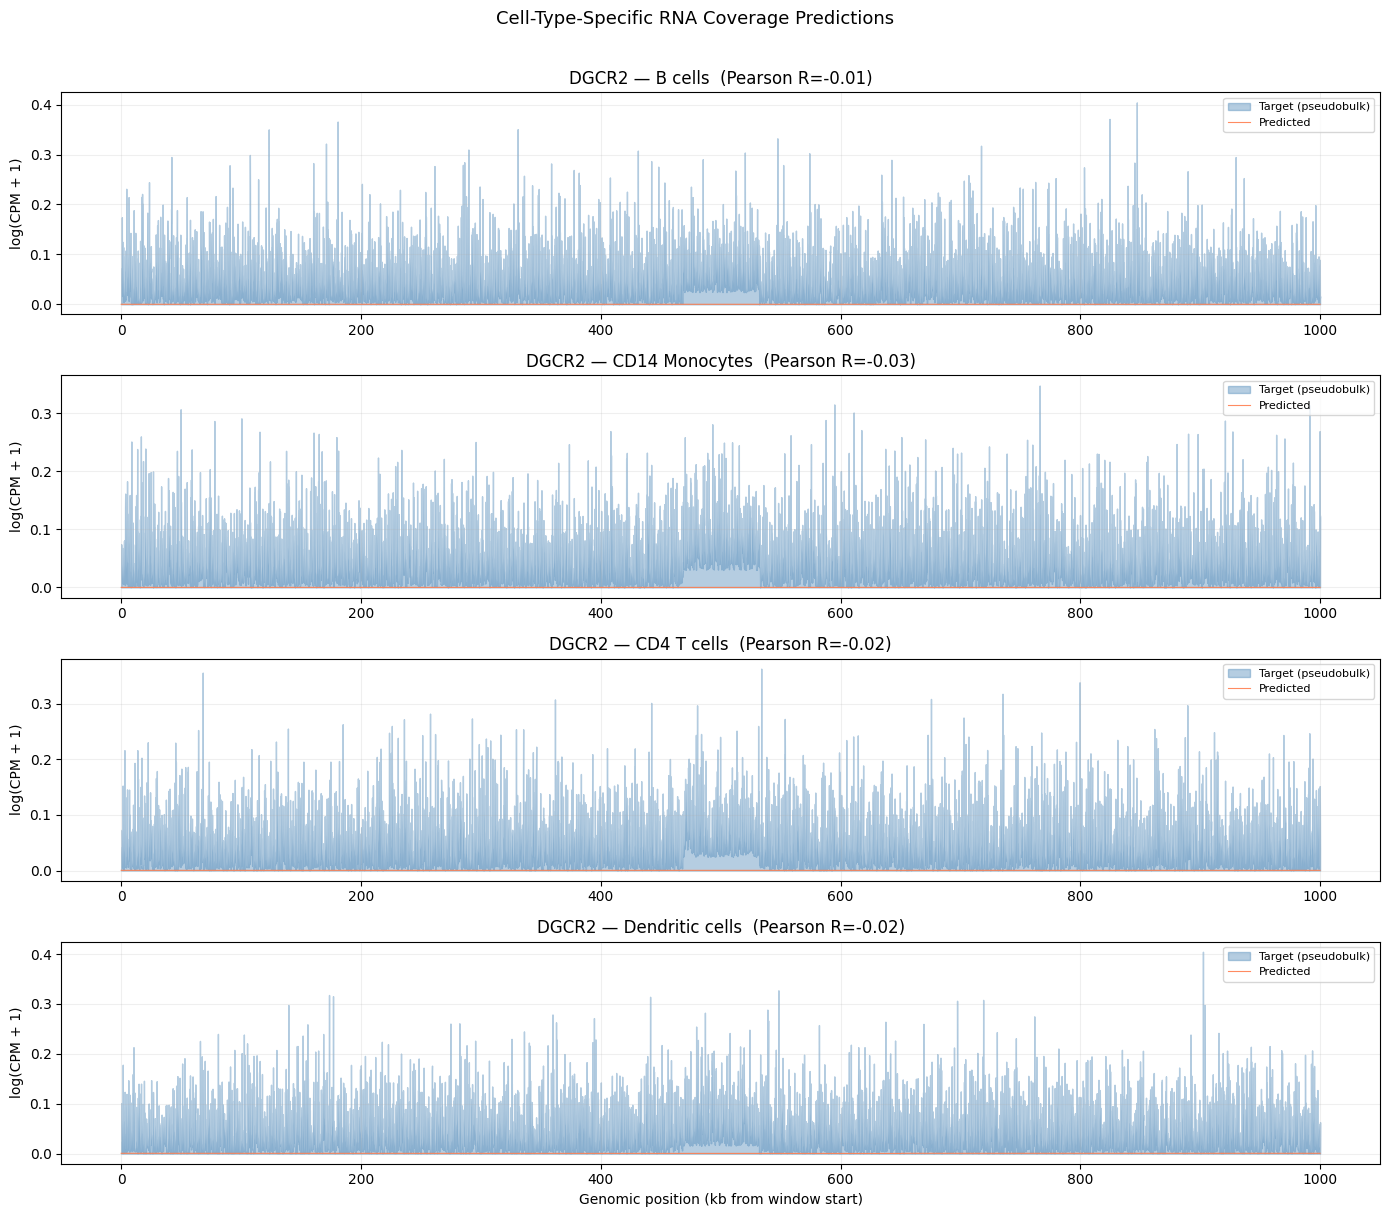

Prediction plots saved.


In [40]:
# --- 7b. Visualise predictions vs targets for a few examples ---

n_examples = min(4, len(test_results))
fig, axes  = plt.subplots(n_examples, 1, figsize=(14, 3 * n_examples), sharex=False)
if n_examples == 1:
    axes = [axes]

for i, sample in enumerate(test_results[:n_examples]):
    bins   = np.arange(N_BINS) * BIN_SIZE / 1000   # kb from window start
    axes[i].fill_between(bins, sample['target'],     alpha=0.4, color='steelblue', label='Target (pseudobulk)')
    axes[i].plot(        bins, sample['prediction'], alpha=0.9, color='coral',     label='Predicted', lw=0.8)
    axes[i].set_title(f"{sample['gene']} — {sample['cell_type']}  "
                      f"(Pearson R={sample['pearson_r']:.2f})")
    axes[i].set_ylabel('log(CPM + 1)')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel('Genomic position (kb from window start)')
plt.suptitle('Cell-Type-Specific RNA Coverage Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/predictions/coverage_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Prediction plots saved.')

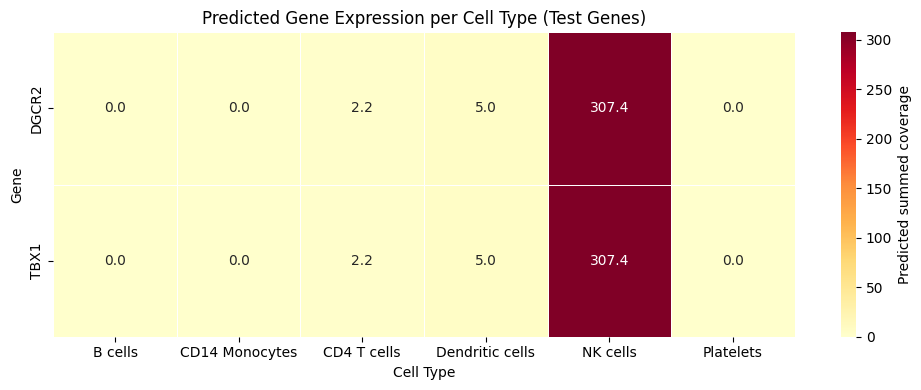

Cell-type heatmap saved.


In [41]:
# --- 7c. Cell-type comparison: how well does the model differentiate cell types? ---
# For each gene in the test set, compare predicted expression across cell types

# Average predicted CPM per gene per cell type (sum over bins as a gene-level proxy)
pred_matrix = {}
for r in test_results:
    gene = r['gene']
    ct   = r['cell_type']
    pred_matrix.setdefault(gene, {})[ct] = float(np.sum(r['prediction']))

if pred_matrix:
    pred_df = pd.DataFrame(pred_matrix).T.fillna(0)

    fig, ax = plt.subplots(figsize=(10, max(4, len(pred_df) * 0.6)))
    sns.heatmap(pred_df, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Predicted summed coverage'})
    ax.set_title('Predicted Gene Expression per Cell Type (Test Genes)')
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('Gene')
    plt.tight_layout()
    plt.savefig('outputs/predictions/cell_type_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Cell-type heatmap saved.')

## Section 8 — Save & Export

In [42]:
# --- 8a. Save trained head parameters ---

# Haiku parameters are plain Python/NumPy dicts — easy to pickle
head_save_path = 'outputs/models/cell_conditioned_head_params.pkl'
with open(head_save_path, 'wb') as f:
    pickle.dump({
        'params':      best_params,
        'cell_types':  cell_types_list,
        'emb_dim':     EMB_DIM,
        'seq_emb_dim': SEQ_EMB_DIM,
        'n_bins':      N_BINS,
        'bin_size':    BIN_SIZE,
    }, f)
print(f'Head parameters saved to: {head_save_path}')

# Save cell type embeddings (needed for inference)
emb_save_path = 'outputs/models/cell_type_embeddings.pkl'
with open(emb_save_path, 'wb') as f:
    pickle.dump(cell_type_embeddings, f)
print(f'Cell type embeddings saved to: {emb_save_path}')

# Save scANVI model
scanvi_model.save('outputs/models/scanvi_model/', overwrite=True)
print('scANVI model saved to: outputs/models/scanvi_model/')

Head parameters saved to: outputs/models/cell_conditioned_head_params.pkl
Cell type embeddings saved to: outputs/models/cell_type_embeddings.pkl
scANVI model saved to: outputs/models/scanvi_model/


In [43]:
# --- 8b. Save test results as CSV ---

results_df.to_csv('outputs/test_set_results.csv', index=False)
print('Test results saved to: outputs/test_set_results.csv')

# Save pseudobulk expression matrix
pseudobulk_df.to_csv('outputs/pseudobulk_cpm.csv')
print('Pseudobulk CPM matrix saved to: outputs/pseudobulk_cpm.csv')

# Save AnnData with scANVI embeddings
adata.write('outputs/pbmc_scanvi.h5ad')
print('AnnData with scANVI embeddings saved to: outputs/pbmc_scanvi.h5ad')

Test results saved to: outputs/test_set_results.csv
Pseudobulk CPM matrix saved to: outputs/pseudobulk_cpm.csv
AnnData with scANVI embeddings saved to: outputs/pbmc_scanvi.h5ad


In [44]:
# --- 8c. Helper: reload and run inference on a new gene/cell-type pair ---

def predict_for_new_sample(gene_name: str, cell_type: str,
                            head_params_path: str = head_save_path,
                            emb_path: str = emb_save_path) -> np.ndarray:
    """
    Convenience function to predict RNA-seq coverage for any gene on chr22
    and any cell type in the training set.

    Returns:
        coverage: (N_BINS,) predicted log-normalised coverage array
    """
    with open(head_params_path, 'rb') as f:
        saved = pickle.load(f)
    params = saved['params']

    with open(emb_path, 'rb') as f:
        embs = pickle.load(f)

    if cell_type not in embs:
        raise ValueError(f'Unknown cell type: {cell_type}. Available: {list(embs.keys())}')

    row = genes_df[genes_df['gene'] == gene_name]
    if row.empty:
        raise ValueError(f'Gene {gene_name} not in gene table. Add it to genes_df first.')

    tss    = int(row.iloc[0]['tss'])
    seq_oh = get_sequence_window('chr22', tss)
    seq_emb  = jnp.array(extract_backbone_embeddings(seq_oh))
    cell_emb = jnp.array(embs[cell_type].astype(np.float32))

    pred = head_fn_eval.apply(params, seq_emb, cell_emb)
    return np.array(jax.nn.softplus(pred))


# Demo call
demo_gene = genes_df.iloc[0]['gene']
demo_ct   = cell_types_list[0]
demo_pred = predict_for_new_sample(demo_gene, demo_ct)
print(f'Demo prediction for {demo_gene} in {demo_ct}: shape={demo_pred.shape}, mean={demo_pred.mean():.4f}')

Input length: 1000000
Output string length: 1048576
Raw embedding shape: (1048576, 13)
Demo prediction for DGCR2 in B cells: shape=(7812,), mean=0.0000


## Section 9 — Summary & Evaluation

In [45]:
# --- 9. Full summary ---

print('=' * 60)
print('  PIPELINE SUMMARY')
print('=' * 60)

print('\n[DATA]')
print(f'  scRNA-seq cells:       {adata.n_obs:,}')
print(f'  Genes after QC:        {adata.n_vars:,}')
print(f'  Cell types detected:   {len(cell_types_list)}')
for ct in cell_types_list:
    n = int((adata.obs['cell_type'] == ct).sum())
    print(f'    {ct}: {n} cells')

print('\n[SCRNA PROCESSING]')
print(f'  scVI latent dim:       20')
print(f'  scANVI latent dim:     20')
print(f'  Cell-type embedding dim: {EMB_DIM}')

print('\n[GENOMIC INTERVALS]')
print(f'  Chromosome:            chr22 (hg38)')
print(f'  Genes:                 {len(genes_df)}')
print(f'  Window size:           {WINDOW_SIZE:,} bp')
print(f'  Bins per window:       {N_BINS} × {BIN_SIZE} bp')

print('\n[DATASET SPLITS]')
print(f'  Train:  {len(train_set):3d} samples | genes: {", ".join(train_genes)}')
print(f'  Val:    {len(val_set):3d} samples | genes: {", ".join(val_genes)}')
print(f'  Test:   {len(test_set):3d} samples | genes: {", ".join(test_genes)}')

print('\n[MODEL]')
print(f'  Backbone:              AlphaGenome fold-0 (frozen)')
print(f'  New head params:       {n_params:,}')
print(f'  Conditioning:          FiLM (scale + shift from cell embedding)')
print(f'  Optimizer:             Adam lr={LEARNING_RATE}')
print(f'  Epochs trained:        {len(train_losses)}')
print(f'  Best val loss:         {best_val_loss:.4f}')

print('\n[TEST SET PERFORMANCE]')
summary = results_df.agg({'pearson_r': ['mean', 'std'], 'spearman_r': ['mean', 'std'], 'mse': ['mean', 'std']})
print(f'  Mean Pearson R:        {results_df.pearson_r.mean():.3f} ± {results_df.pearson_r.std():.3f}')
print(f'  Mean Spearman R:       {results_df.spearman_r.mean():.3f} ± {results_df.spearman_r.std():.3f}')
print(f'  Mean MSE:              {results_df.mse.mean():.4f} ± {results_df.mse.std():.4f}')

print('\n[SAVED OUTPUTS]')
for p in sorted(Path('outputs').rglob('*')):
    if p.is_file():
        size = p.stat().st_size
        unit = 'KB' if size < 1e6 else 'MB'
        print(f'  {str(p):<55} {size/1e3 if size < 1e6 else size/1e6:.1f} {unit}')

print('\n' + '=' * 60)
print('  Pipeline complete.')
print('=' * 60)

  PIPELINE SUMMARY

[DATA]
  scRNA-seq cells:       2,643
  Genes after QC:        13,714
  Cell types detected:   6
    B cells: 342 cells
    CD14 Monocytes: 483 cells
    CD4 T cells: 1099 cells
    Dendritic cells: 213 cells
    NK cells: 495 cells
    Platelets: 11 cells

[SCRNA PROCESSING]
  scVI latent dim:       20
  scANVI latent dim:     20
  Cell-type embedding dim: 20

[GENOMIC INTERVALS]
  Chromosome:            chr22 (hg38)
  Genes:                 10
  Window size:           1,000,000 bp
  Bins per window:       7812 × 128 bp

[DATASET SPLITS]
  Train:   36 samples | genes: APOL1, CRKL, SCO2, EP300, MAPK8IP2, SYNGR1
  Val:     12 samples | genes: MKL1, HMOX1
  Test:    12 samples | genes: TBX1, DGCR2

[MODEL]
  Backbone:              AlphaGenome fold-0 (frozen)
  New head params:       458,241
  Conditioning:          FiLM (scale + shift from cell embedding)
  Optimizer:             Adam lr=0.001
  Epochs trained:        6
  Best val loss:         0.0050

[TEST SET PERFO